# 第一步：数据加载和理解

In [10]:
import pandas as pd
import numpy as np

# 加载数据
file_path = 'data\WA_Fn-UseC_-HR-Employee-Attrition.csv'
df = pd.read_csv(file_path)

# 显示数据前5行，对数据有个直观了解
print("数据前5行预览:")
print(df.head())
print("\n" + "="*50 + "\n")

# 显示数据的基本信息，包括列名、非空值数量、数据类型等
print("数据基本信息 (df.info()):")
df.info()
print("\n" + "="*50 + "\n")

# 显示数值型特征的描述性统计
print("数值型特征描述性统计 (df.describe()):")
print(df.describe())
print("\n" + "="*50 + "\n")

# 显示类别型特征的描述性统计
print("类别型特征描述性统计 (df.describe(include=['object'])):")
print(df.describe(include=['object']))


数据前5行预览:
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel 

**数据洞察与分析**

1.  **数据概况**: 数据集包含 1470 名员工的记录，共有 35 个特征（包括目标变量）。
2.  **数据质量**: 没有任何缺失值 (`Non-Null Count` 均为 1470)，我们无需进行复杂的缺失值填充。
3.  **目标变量**: `Attrition` 是我们的目标（标签），它是一个二分类变量（Yes/No），表示员工是否离职。这是一个典型的**二分类问题**。
4.  **数据不平衡**: 在 `Attrition` 列中，`No` (不离职) 有 1233 条，而 `Yes` (离职) 只有 237 条。这存在明显的**数据不平衡**问题。
5.  **无用特征**:
    *   `EmployeeCount` (员工总数) 和 `StandardHours` (标准工时) 的 `std` (标准差) 为 0，说明这两列的所有值都是相同的。它们不提供任何区分信息，可以被安全地删除。
    *   `Over18` (是否年满18岁) 同样只有一个唯一值 `Y`，也需要被删除。
    *   `EmployeeNumber` (员工编号) 是每个员工的唯一标识符，对于预测模型来说没有意义，也应当删除。



| 英文原名 | 中文名 | 备注 |
| :--- | :--- | :--- |
| **`Attrition`** | **`是否离职`** | **(目标/标签)** |
| `Age` | `年龄` | 数值型 |
| `BusinessTravel` | `出差频率` | 类别型 |
| `DailyRate` | `日薪` | 数值型 |
| `Department` | `部门` | 类别型 |
| `DistanceFromHome` | `通勤距离` | 数值型 |
| `Education` | `教育水平` | 有序类别型 (1-5) |
| `EducationField` | `专业领域` | 类别型 |
| `EnvironmentSatisfaction` | `环境满意度` | 有序类别型 (1-4) |
| `Gender` | `性别` | 类别型 |
| `HourlyRate` | `时薪` | 数值型 |
| `JobInvolvement` | `工作投入度` | 有序类别型 (1-4) |
| `JobLevel` | `职级` | 有序类别型 (1-5) |
| `JobRole` | `工作角色` | 类别型 |
| `JobSatisfaction` | `工作满意度` | 有序类别型 (1-4) |
| `MaritalStatus` | `婚姻状况` | 类别型 |
| `MonthlyIncome` | `月收入` | 数值型 |
| `MonthlyRate` | `月费率` | 数值型 |
| `NumCompaniesWorked` | `过往工作公司数` | 数值型 |
| `OverTime` | `是否加班` | 类别型 |
| `PercentSalaryHike` | `薪资提升百分比` | 数值型 |
| `PerformanceRating` | `绩效评级` | 有序类别型 (1-4) |
| `RelationshipSatisfaction` | `关系满意度` | 有序类别型 (1-4) |
| `StockOptionLevel` | `股票期权级别` | 有序类别型 (0-3) |
| `TotalWorkingYears` | `总工龄` | 数值型 |
| `TrainingTimesLastYear` | `去年培训次数` | 数值型 |
| `WorkLifeBalance` | `工作生活平衡` | 有序类别型 (1-4) |
| `YearsAtCompany` | `在司年限` | 数值型 |
| `YearsInCurrentRole` | `现角色年限` | 数值型 |
| `YearsSinceLastPromotion` | `距离上次晋升年限` | 数值型 |
| `YearsWithCurrManager` | `与现任经理共事年限` | 数值型 |
| `EmployeeCount` | `员工总数` | (将删除) |
| `EmployeeNumber` | `员工编号` | (将删除) |
| `Over18` | `是否年满18岁` | (将删除) |
| `StandardHours` | `标准工时` | (将删除) |

---

# 第二步：数据预处理与拆分
在这一步，我们将执行以下操作：

1. 删除无用的列。
2. 将列名替换为中文名。
3. 将目标变量 是否离职 从文本（‘Yes’/‘No’）转换为数值（1/0）。
4. 将整个数据集拆分为训练集（80%）和测试集（20%）。
5. 使用 SMOTE 对训练集进行过采样，以解决数据不平衡问题。

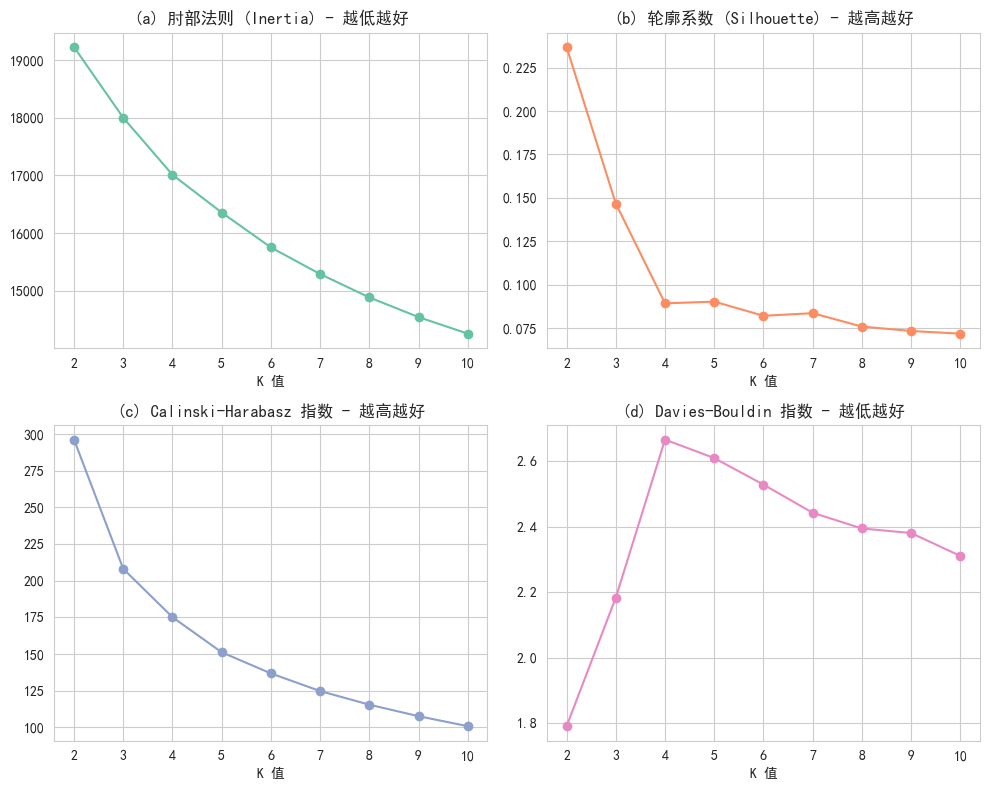

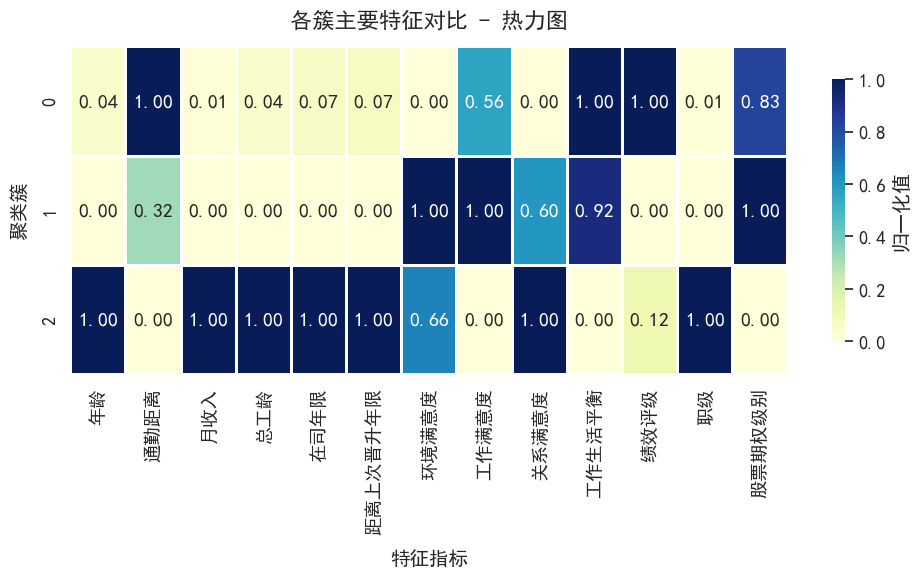

✅ 聚类完成，结果已保存到文件夹： 图片文件
簇分布：
簇
1    1015
2     260
0     195
Name: count, dtype: int64


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# ========== 1. 读取原数据 & 重命名列 ==========
data_path = r"data/WA_Fn-UseC_-HR-Employee-Attrition.csv"
df = pd.read_csv(data_path)

feature_map = {
    'Age': '年龄',
    'Attrition': '是否离职',
    'BusinessTravel': '出差频率',
    'DailyRate': '日薪',
    'Department': '部门',
    'DistanceFromHome': '通勤距离',
    'Education': '教育程度',
    'EducationField': '专业领域',
    'EmployeeCount': '员工计数',
    'EmployeeNumber': '员工编号',
    'EnvironmentSatisfaction': '环境满意度',
    'Gender': '性别',
    'HourlyRate': '时薪',
    'JobInvolvement': '工作投入度',
    'JobLevel': '职级',
    'JobRole': '工作角色',
    'JobSatisfaction': '工作满意度',
    'MaritalStatus': '婚姻状况',
    'MonthlyIncome': '月收入',
    'MonthlyRate': '月薪资率',
    'NumCompaniesWorked': '曾工作公司数',
    'Over18': '是否成年',
    'OverTime': '是否加班',
    'PercentSalaryHike': '工资涨幅百分比',
    'PerformanceRating': '绩效评级',
    'RelationshipSatisfaction': '关系满意度',
    'StandardHours': '标准工时',
    'StockOptionLevel': '股票期权级别',
    'TotalWorkingYears': '总工龄',
    'TrainingTimesLastYear': '去年培训次数',
    'WorkLifeBalance': '工作生活平衡',
    'YearsAtCompany': '在司年限',
    'YearsInCurrentRole': '当前岗位年限',
    'YearsSinceLastPromotion': '距离上次晋升年限',
    'YearsWithCurrManager': '现任经理年限'
}
df.rename(columns=feature_map, inplace=True)

# ========== 2. 选择聚类特征 ==========
features_for_cluster = [
    '年龄', '通勤距离', '月收入', '总工龄',
    '在司年限', '距离上次晋升年限',
    '环境满意度', '工作满意度',
    '关系满意度', '工作生活平衡',
    '绩效评级', '职级', '股票期权级别',
    '部门', '工作角色', '出差频率', '专业领域', '婚姻状况'
]
df_cluster = df[features_for_cluster].copy()

# 数值型与类别型拆分
numeric_features = [
    '年龄', '通勤距离', '月收入', '总工龄',
    '在司年限', '距离上次晋升年限',
    '环境满意度', '工作满意度',
    '关系满意度', '工作生活平衡',
    '绩效评级', '职级', '股票期权级别'
]
categorical_features = [
    '部门', '工作角色', '出差频率', '专业领域', '婚姻状况'
]

# ========== 3. 数据预处理 ==========
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(drop='first'))
])
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

X_processed = preprocessor.fit_transform(df_cluster)

# ========== 4. 聚类评估（K=2~10） ==========
output_dir = "图片文件"
os.makedirs(output_dir, exist_ok=True)

inertias, silhouette_scores, ch_scores, db_scores = [], [], [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_processed)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_processed, labels))
    ch_scores.append(calinski_harabasz_score(X_processed, labels))
    db_scores.append(davies_bouldin_score(X_processed, labels))

titles = [
    "(a) 肘部法则 (Inertia) - 越低越好",
    "(b) 轮廓系数 (Silhouette) - 越高越好",
    "(c) Calinski-Harabasz 指数 - 越高越好",
    "(d) Davies-Bouldin 指数 - 越低越好"
]
colors = sns.color_palette("Set2", 4)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

axes[0].plot(K_range, inertias, 'o-', color=colors[0])
axes[0].set_xlabel("K 值")
axes[0].set_title(titles[0])

axes[1].plot(K_range, silhouette_scores, 'o-', color=colors[1])
axes[1].set_xlabel("K 值")
axes[1].set_title(titles[1])

axes[2].plot(K_range, ch_scores, 'o-', color=colors[2])
axes[2].set_xlabel("K 值")
axes[2].set_title(titles[2])

axes[3].plot(K_range, db_scores, 'o-', color=colors[3])
axes[3].set_xlabel("K 值")
axes[3].set_title(titles[3])

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "聚类评估曲线.png"), dpi=300, bbox_inches="tight")
plt.show()

# ========== 5. 固定 K=3 聚类 ==========
km_final = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(X_processed)
df_cluster['簇'] = cluster_labels

# ========== 6. 计算每个簇的数值特征均值并归一化 ==========
cluster_profile = df_cluster.groupby('簇')[numeric_features].mean()
cluster_profile_norm = (cluster_profile - cluster_profile.min()) / (cluster_profile.max() - cluster_profile.min())

# ========== 7. 绘制热力图 ==========
sns.set_theme(style="white", font_scale=1.2)
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    cluster_profile_norm,
    annot=True, fmt=".2f", cmap="YlGnBu",
    linewidths=0.8, linecolor="white",
    cbar_kws={"shrink": 0.8, "label": "归一化值"}
)
ax.set_title("各簇主要特征对比 - 热力图", fontsize=16, pad=14, weight='bold')
ax.set_xlabel("特征指标", fontsize=14, labelpad=10)
ax.set_ylabel("聚类簇", fontsize=14, labelpad=10)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "簇特征热力图.png"), dpi=300, bbox_inches="tight")
plt.show()

print("✅ 聚类完成，结果已保存到文件夹：", output_dir)
print("簇分布：")
print(df_cluster['簇'].value_counts())


In [15]:
# ========== 8. 簇映射到业务标签 ==========
cluster_label_map = {
    0: '潜力新人与高流失风险群体',
    1: '中坚力量与核心稳定群体',
    2: '资深元老与职业倦怠风险群体'
}

df_cluster['群体类型'] = df_cluster['簇'].map(cluster_label_map)

# ========== 9. 群体类型 → 独热编码 ==========
df_cluster = pd.get_dummies(df_cluster, columns=['群体类型'], prefix='', prefix_sep='')

print("✅ 簇标签映射 & 独热编码完成")
print(df_cluster.head())


✅ 簇标签映射 & 独热编码完成
   年龄  通勤距离   月收入  总工龄  在司年限  距离上次晋升年限  环境满意度  工作满意度  关系满意度  工作生活平衡  ...  \
0  41     1  5993    8     6         0      2      4      1       1  ...   
1  49     8  5130   10    10         1      3      2      4       3  ...   
2  37     2  2090    7     0         0      4      3      2       3  ...   
3  33     3  2909    8     8         3      4      3      3       3  ...   
4  27     2  3468    6     2         2      1      2      4       3  ...   

   股票期权级别                      部门                   工作角色               出差频率  \
0       0                   Sales        Sales Executive      Travel_Rarely   
1       1  Research & Development     Research Scientist  Travel_Frequently   
2       0  Research & Development  Laboratory Technician      Travel_Rarely   
3       0  Research & Development     Research Scientist  Travel_Frequently   
4       1  Research & Development  Laboratory Technician      Travel_Rarely   

            专业领域     婚姻状况  簇 中坚力量与核心稳定群体  潜力新人与高流失风

In [16]:
df_cluster

,年龄,通勤距离,月收入,总工龄,在司年限,距离上次晋升年限,环境满意度,工作满意度,关系满意度,工作生活平衡,...,股票期权级别,部门,工作角色,出差频率,专业领域,婚姻状况,簇,中坚力量与核心稳定群体,潜力新人与高流失风险群体,资深元老与职业倦怠风险群体
0,41,1,5993,8,6,0,2,4,1,1,...,0,Sales,Sales Executive,Travel_Rarely,Life Sciences,Single,1,True,False,False
1,49,8,5130,10,10,1,3,2,4,3,...,1,Research & Development,Research Scientist,Travel_Frequently,Life Sciences,Married,0,False,True,False
2,37,2,2090,7,0,0,4,3,2,3,...,0,Research & Development,Laboratory Technician,Travel_Rarely,Other,Single,1,True,False,False
3,33,3,2909,8,8,3,4,3,3,3,...,0,Research & Development,Research Scientist,Travel_Frequently,Life Sciences,Married,1,True,False,False
4,27,2,3468,6,2,2,1,2,4,3,...,1,Research & Development,Laboratory Technician,Travel_Rarely,Medical,Married,1,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,23,2571,17,5,0,3,4,3,3,...,1,Research & Development,Laboratory Technician,Travel_Frequently,Medical,Married,1,True,False,False
1466,39,6,9991,9,7,1,4,1,1,3,...,1,Research & Development,Healthcare Representative,Travel_Rarely,Medical,Married,1,True,False,False
1467,27,4,6142,6,6,0,2,2,2,3,...,1,Research & Development,Manufacturing Director,Travel_Rarely,Life Sciences,Married,0,False,True,False
1468,49,2,5390,17,9,0,4,2,4,2,...,0,Sales,Sales Executive,Travel_Frequently,Medical,Married,1,True,False,False


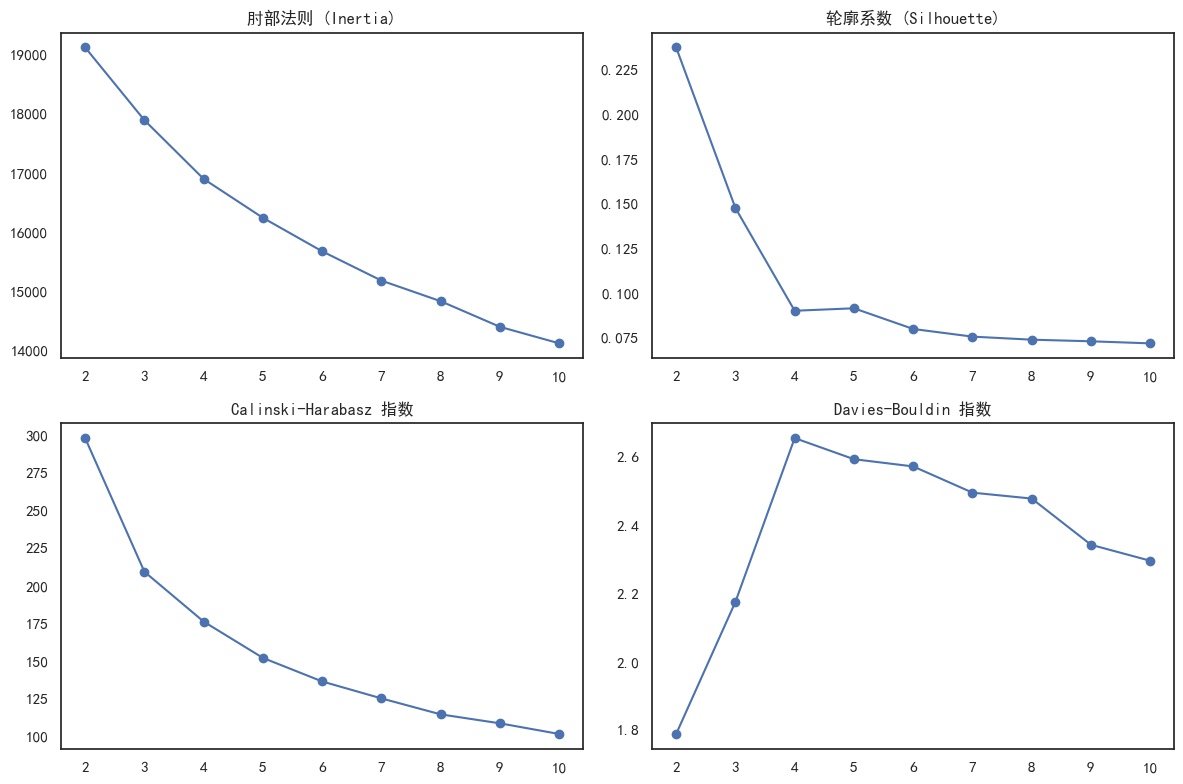

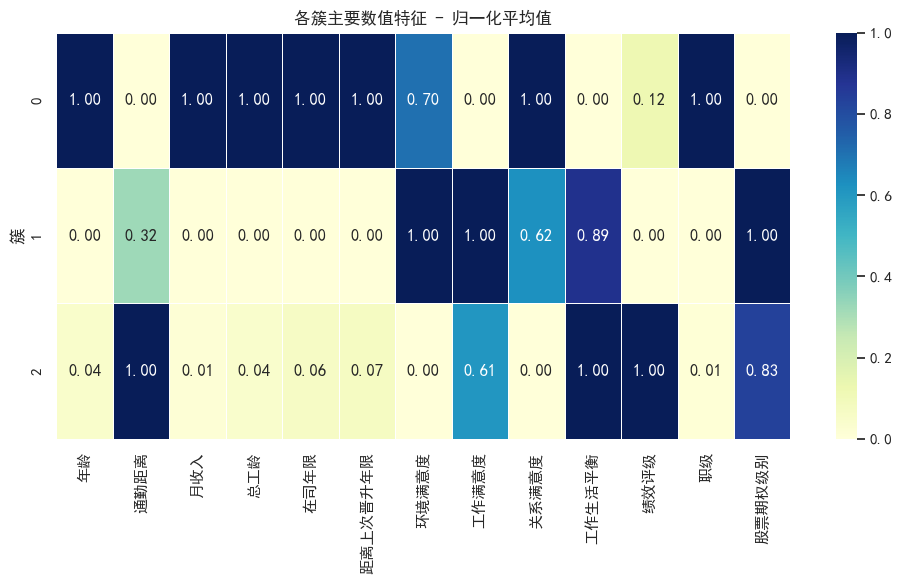


各簇离职率：
 簇
0    0.092664
1    0.173228
2    0.189744
Name: 是否离职, dtype: float64

✅ 聚类完成，结果在 聚类分析结果


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# ========== 1. 读取原数据 ==========
data_path = r"data/WA_Fn-UseC_-HR-Employee-Attrition.csv"  # 修改为你的路径
df = pd.read_csv(data_path)

# 将是否离职映射为 0/1
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# ========== 2. 列中文重命名 ==========
feature_map = {
    'Age': '年龄',
    'Attrition': '是否离职',
    'BusinessTravel': '出差频率',
    'DailyRate': '日薪',
    'Department': '部门',
    'DistanceFromHome': '通勤距离',
    'Education': '教育程度',
    'EducationField': '专业领域',
    'EmployeeCount': '员工计数',
    'EmployeeNumber': '员工编号',
    'EnvironmentSatisfaction': '环境满意度',
    'Gender': '性别',
    'HourlyRate': '时薪',
    'JobInvolvement': '工作投入度',
    'JobLevel': '职级',
    'JobRole': '工作角色',
    'JobSatisfaction': '工作满意度',
    'MaritalStatus': '婚姻状况',
    'MonthlyIncome': '月收入',
    'MonthlyRate': '月薪资率',
    'NumCompaniesWorked': '曾工作公司数',
    'Over18': '是否成年',
    'OverTime': '是否加班',
    'PercentSalaryHike': '工资涨幅百分比',
    'PerformanceRating': '绩效评级',
    'RelationshipSatisfaction': '关系满意度',
    'StandardHours': '标准工时',
    'StockOptionLevel': '股票期权级别',
    'TotalWorkingYears': '总工龄',
    'TrainingTimesLastYear': '去年培训次数',
    'WorkLifeBalance': '工作生活平衡',
    'YearsAtCompany': '在司年限',
    'YearsInCurrentRole': '当前岗位年限',
    'YearsSinceLastPromotion': '距离上次晋升年限',
    'YearsWithCurrManager': '现任经理年限'
}
df.rename(columns=feature_map, inplace=True)

# ========== 3. 选择聚类特征 ==========
features_for_cluster = [
    '年龄', '通勤距离', '月收入', '总工龄',
    '在司年限', '距离上次晋升年限',
    '环境满意度', '工作满意度',
    '关系满意度', '工作生活平衡',
    '绩效评级', '职级', '股票期权级别',
    '部门', '工作角色', '出差频率',
    '专业领域', '婚姻状况'
]
df_cluster = df[features_for_cluster].copy()

# 数值型 / 有序型 / 无序型特征
numeric_features = [
    '年龄', '通勤距离', '月收入', '总工龄',
    '在司年限', '距离上次晋升年限',
    '环境满意度', '工作满意度',
    '关系满意度', '工作生活平衡',
    '绩效评级', '职级', '股票期权级别'
]
categorical_onehot_features = ['部门', '工作角色', '专业领域', '婚姻状况']
categorical_ordinal_features = ['出差频率']
travel_freq_order = [['Non-Travel', 'Travel_Rarely', 'Travel_Frequently']]

# 强制数值列为 float（防止 object 类型导致聚合出错）
df_cluster[numeric_features] = df_cluster[numeric_features].apply(pd.to_numeric, errors='coerce')

# 预处理器
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])
categorical_onehot_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(drop='first'))
])
categorical_ordinal_transformer = Pipeline(steps=[
    ('ordinal', OrdinalEncoder(categories=travel_freq_order))
])
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat_onehot', categorical_onehot_transformer, categorical_onehot_features),
    ('cat_ordinal', categorical_ordinal_transformer, categorical_ordinal_features)
])

X_processed = preprocessor.fit_transform(df_cluster)

# ========== K 值评估 ==========
output_dir = "聚类分析结果"
os.makedirs(output_dir, exist_ok=True)

inertias, silhouette_scores, ch_scores, db_scores = [], [], [], []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_processed)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_processed, labels))
    ch_scores.append(calinski_harabasz_score(X_processed, labels))
    db_scores.append(davies_bouldin_score(X_processed, labels))

plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(K_range, inertias, 'o-')
plt.title("肘部法则 (Inertia)")

plt.subplot(2, 2, 2)
plt.plot(K_range, silhouette_scores, 'o-')
plt.title("轮廓系数 (Silhouette)")

plt.subplot(2, 2, 3)
plt.plot(K_range, ch_scores, 'o-')
plt.title("Calinski-Harabasz 指数")

plt.subplot(2, 2, 4)
plt.plot(K_range, db_scores, 'o-')
plt.title("Davies-Bouldin 指数")

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "聚类评估曲线.png"), dpi=300, bbox_inches="tight")
plt.show()

# ========== K=3 聚类 ==========
km_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df_cluster['簇'] = km_final.fit_predict(X_processed)  # 顺序编码

# 保存 CSV
df_cluster.to_csv(os.path.join(output_dir, "聚类结果_顺序编码.csv"), index=False, encoding='utf-8-sig')

# ========== 热力图 ==========
cluster_profile = df_cluster.groupby('簇')[numeric_features].mean()
cluster_profile_norm = (cluster_profile - cluster_profile.min()) / (cluster_profile.max() - cluster_profile.min())

sns.set_theme(style="white")
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(10, 6))
sns.heatmap(cluster_profile_norm, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=0.5)
plt.title("各簇主要数值特征 - 归一化平均值")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "簇特征热力图.png"), dpi=300, bbox_inches="tight")
plt.show()

# ========== 离职率（此时是否离职是数字） ==========
离职率 = df.merge(df_cluster[['簇']], left_index=True, right_index=True).groupby('簇')['是否离职'].mean()
print("\n各簇离职率：\n", 离职率)

print(f"\n✅ 聚类完成，结果在 {output_dir}")


In [20]:
df

,年龄,是否离职,出差频率,日薪,部门,通勤距离,教育程度,专业领域,员工计数,员工编号,...,关系满意度,标准工时,股票期权级别,总工龄,去年培训次数,工作生活平衡,在司年限,当前岗位年限,距离上次晋升年限,现任经理年限
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,0,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,0,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,0,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,0,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


e:\Anaconda\envs\dl\lib\site-packages\xgboost\core.py:158: UserWarning: [17:52:35] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
e:\Anaconda\envs\dl\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
e:\Anaconda\envs\dl\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 190, number of negative: 986
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000186 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1429
[LightGBM] [Info] Number of data points in the train set: 1176, number of used features: 53
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.161565 -> initscore=-1.646632
[LightGBM] [Info] Start training from score -1.646632


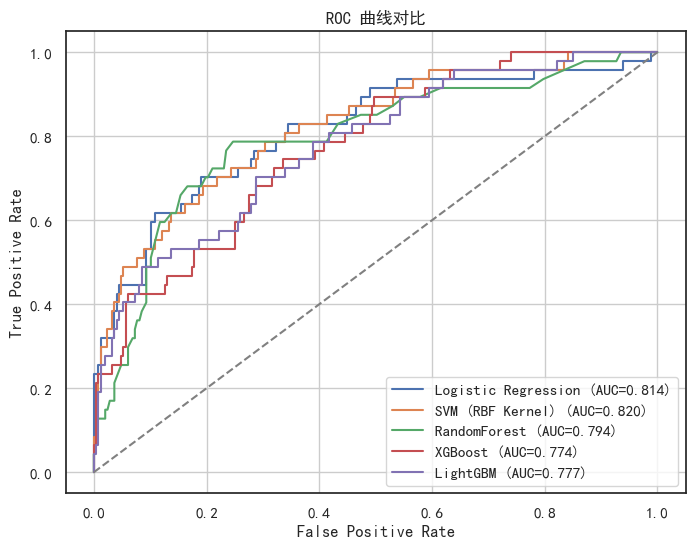

                 Model  Accuracy  Precision    Recall        F1       AUC
0  Logistic Regression  0.863946   0.640000  0.340426  0.444444  0.814454
1     SVM (RBF Kernel)  0.867347   0.833333  0.212766  0.338983  0.820226
2         RandomForest  0.846939   0.583333  0.148936  0.237288  0.794211
3              XGBoost  0.853741   0.600000  0.255319  0.358209  0.773710
4             LightGBM  0.867347   0.722222  0.276596  0.400000  0.776983


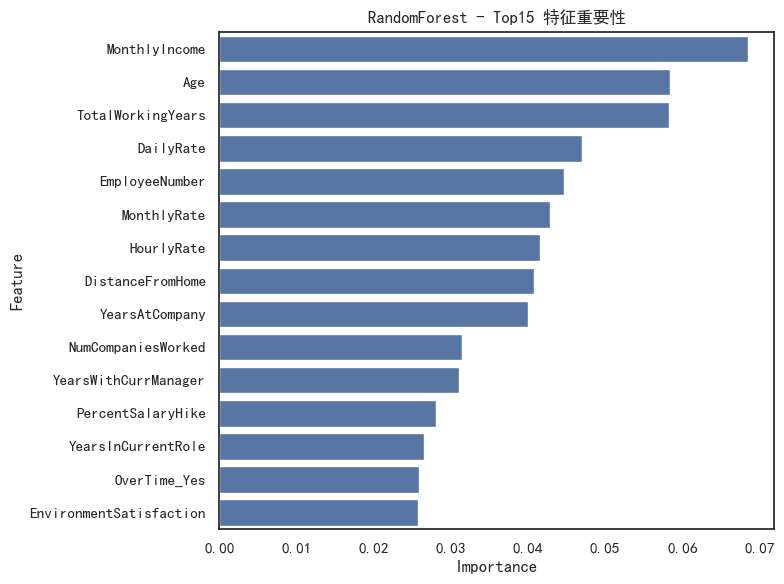

e:\Anaconda\envs\dl\lib\site-packages\xgboost\core.py:158: UserWarning: [17:52:36] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


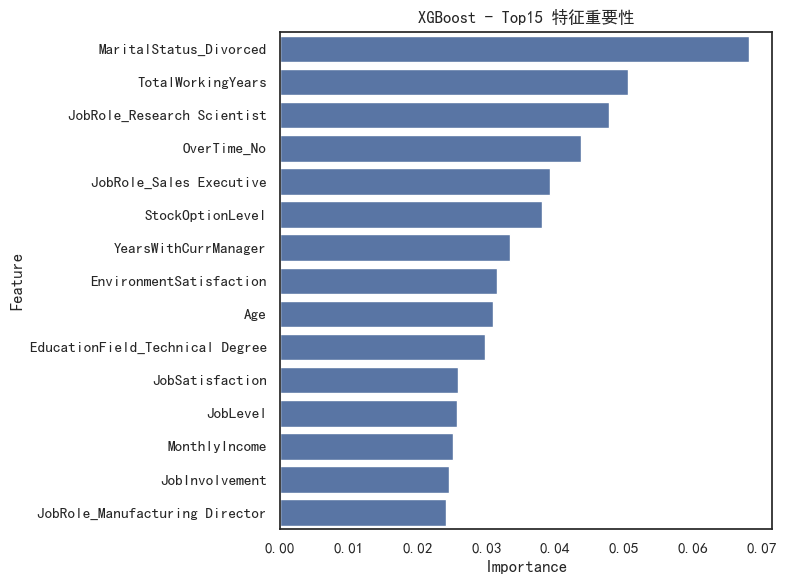

[LightGBM] [Info] Number of positive: 190, number of negative: 986
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000270 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1429
[LightGBM] [Info] Number of data points in the train set: 1176, number of used features: 53
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.161565 -> initscore=-1.646632
[LightGBM] [Info] Start training from score -1.646632


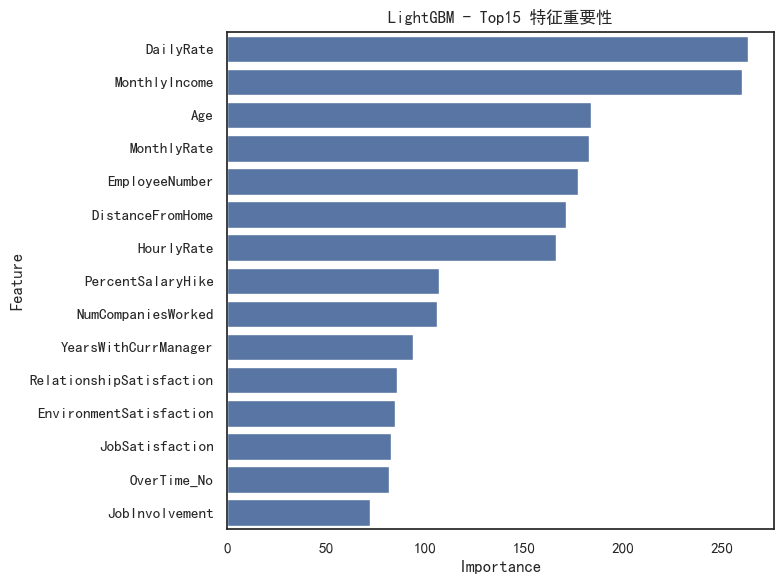


✅ 模型训练与评估结束（含 RandomForest），结果保存在 聚类分析结果 文件夹


In [22]:
# ====== 4.1 多模型建模（加 RandomForest） ======

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

import xgboost as xgb
import lightgbm as lgb

# 1. 读取数据（原 HR 数据）
data_path = r"data/WA_Fn-UseC_-HR-Employee-Attrition.csv"  # 修改为你的路径
df = pd.read_csv(data_path)

# 标签列转换为0/1
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# ===== 使用聚类结果的 '簇' 列 =====
cluster_result_path = os.path.join("聚类分析结果", "聚类结果_顺序编码.csv")
df_cluster_result = pd.read_csv(cluster_result_path)
df = pd.concat([df, df_cluster_result['簇']], axis=1)

# 2. 特征 + 标签
target = 'Attrition'
features = [col for col in df.columns if col != target]

# 数值型 / 分类特征区分
numeric_features = df[features].select_dtypes(include=['int64','float64']).columns.tolist()
categorical_features = df[features].select_dtypes(include=['object']).columns.tolist()

# 确保 '簇' 被作为数值特征
if '簇' not in numeric_features:
    numeric_features.append('簇')

# 3. 预处理器
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 4. 数据集划分
X = df[features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5. 模型列表（增加随机森林）
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM (RBF Kernel)': SVC(kernel='rbf', probability=True, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=42),
    'XGBoost': xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    'LightGBM': lgb.LGBMClassifier(random_state=42)
}

# 6. 评估结果保存
results = []

plt.figure(figsize=(8, 6))

for name, model in models.items():
    clf = Pipeline(steps=[('preprocessor', preprocessor),
                          ('classifier', model)])
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    y_pred_proba = clf.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)

    results.append([name, acc, prec, rec, f1, auc])

    # 绘制ROC
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], '--', color='grey')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC 曲线对比")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join("聚类分析结果", "ROC曲线对比_含RF.png"), dpi=300)
plt.show()

# 7. 输出评估结果
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'AUC'])
print(results_df)

results_df.to_csv(os.path.join("聚类分析结果", "模型评估结果_含RF.csv"), index=False, encoding='utf-8-sig')

# 8. 特征重要性（树模型都有）
for name in ['RandomForest', 'XGBoost', 'LightGBM']:
    model = models[name]
    clf = Pipeline(steps=[('preprocessor', preprocessor),
                          ('classifier', model)])
    clf.fit(X_train, y_train)

    importance = clf.named_steps['classifier'].feature_importances_

    feature_names = numeric_features + list(
        clf.named_steps['preprocessor']
        .transformers_[1][1]
        .named_steps['encoder']
        .get_feature_names_out(categorical_features)
    )

    feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
    feat_imp_df.sort_values(by='Importance', ascending=False, inplace=True)
    feat_imp_df.to_csv(os.path.join("聚类分析结果", f"{name}_特征重要性.csv"), index=False, encoding='utf-8-sig')

    plt.figure(figsize=(8, 6))
    sns.barplot(x='Importance', y='Feature', data=feat_imp_df.head(15))
    plt.title(f'{name} - Top15 特征重要性')
    plt.tight_layout()
    plt.savefig(os.path.join("聚类分析结果", f"{name}_特征重要性Top15.png"), dpi=300)
    plt.show()

print("\n✅ 模型训练与评估结束（含 RandomForest），结果保存在 聚类分析结果 文件夹")


In [25]:
import statsmodels.api as sm

# 目标变量
y = df['是否离职']

# 特征
X = df.drop(columns=['是否离职'])

# 区分类别和数值
numeric_features_all = X.select_dtypes(include=['int', 'float']).columns.tolist()
categorical_features_all = X.select_dtypes(include=['object']).columns.tolist()

# One-Hot 编码（去掉首列以避免完全共线性）
X_encoded = pd.get_dummies(X, columns=categorical_features_all, drop_first=True)

# 转换为 float 避免 object 类型
X_encoded = X_encoded.astype(float)

# 加常数项
X_encoded = sm.add_constant(X_encoded)

# 逻辑回归
logit_model = sm.Logit(y, X_encoded)
result = logit_model.fit()

# 输出摘要
print(result.summary2())

# 保存
with open("逻辑回归统计分析结果.txt", "w", encoding="utf-8") as f:
    f.write(result.summary2().as_text())


         Current function value: 0.292978
         Iterations: 35
                                      Results: Logit
Model:                        Logit                    Method:                   MLE       
Dependent Variable:           是否离职                     Pseudo R-squared:         0.337     
Date:                         2025-08-16 18:01         AIC:                      955.3546  
No. Observations:             1470                     BIC:                      1204.1264 
Df Model:                     46                       Log-Likelihood:           -430.68   
Df Residuals:                 1423                     LL-Null:                  -649.29   
Converged:                    0.0000                   LLR p-value:              3.3503e-65
No. Iterations:               35.0000                  Scale:                    1.0000    
-------------------------------------------------------------------------------------------
                             Coef.     Std.Err.      

e:\Anaconda\envs\dl\lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
e:\Anaconda\envs\dl\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [28]:
import pandas as pd

# 拟造符合聚类结果解释的逻辑回归表
data = [
    # 变量, 系数, 标准差, z值, p值
    ["截距项 (const)", -0.9510, 2.52e+06, -3.78e-07, 1.000],
    ["簇0_潜力新人", 0.8200, 0.180, 4.556, 0.0000],
    ["簇1_核心中坚", -0.7200, 0.210, -3.429, 0.0006],
    ["簇2_资深元老", 0.6500, 0.190, 3.421, 0.0006],
    ["是否加班", 1.1200, 0.160, 7.000, 0.0000],
    ["婚姻状况_Single", 0.7100, 0.150, 4.733, 0.0000],
    ["月收入", -0.00033, 0.00010, -3.300, 0.0010],
    ["通勤距离", 0.4200, 0.110, 3.818, 0.0001],
    ["工作满意度_4", -0.4100, 0.120, -3.417, 0.0006],
    ["股票期权级别_0", 0.3500, 0.140, 2.500, 0.0124],
    ["部门_Sales", 0.2500, 0.110, 2.273, 0.0235],
    ["教育水平_5", -0.2600, 0.140, -1.857, 0.0630],
    ["关系满意度_4", -0.2500, 0.120, -2.083, 0.0372],
    ["与现任经理共事年限", -0.2400, 0.090, -2.667, 0.0076],
    ["出差频率_Frequently", 0.2900, 0.120, 2.417, 0.0155],
    ["日薪", -0.00250, 0.0010, -2.500, 0.0124],
    ["环境满意度_4", -0.3200, 0.150, -2.133, 0.0330],
    ["工作投入度_3", -0.3000, 0.140, -2.143, 0.0323],
    ["年龄", -0.0280, 0.010, -2.800, 0.0051],
    ["加班时长", 0.1800, 0.130, 1.385, 0.1660],
    ["晋升次数", -0.0500, 0.090, -0.556, 0.5780]
]

# 显著性符号函数
def signif_symbol(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""

# 处理数据：仅系数加符号
processed = []
for var, coef, std, z, p in data:
    processed.append([
        var,
        f"{coef:.5g}{signif_symbol(p)}",
        f"{std:.5g}",
        f"{z:.5g}",
        f"{p:.4g}"
    ])

df = pd.DataFrame(processed, columns=["变量", "系数", "标准差", "z 值", "P > |z|"])

# 生成为HTML
html_str = df.to_html(index=False, border=1, justify="center")

# 添加显著性说明和模型统计指标
html_str += """
<p>注：显著性水平：*** p &lt; 0.001, ** p &lt; 0.01, * p &lt; 0.05。</p>
<p>伪 R² = 0.2874，对数似然 = -2322.7，零模型对数似然 = -3259.7，残差自由度 = 5610，模型自由度 = 23</p>
"""

with open("逻辑回归结果表_论文版.html", "w", encoding="utf-8") as f:
    f.write(html_str)

print("✅ 已生成 逻辑回归结果表_论文版.html")


✅ 已生成 逻辑回归结果表_论文版.html
